In [1]:
import numpy as np
from pathlib import Path
import os, sys
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm
import warnings
import mne
from scipy.optimize import minimize
from scipy.stats import norm, skewnorm
from math import ceil


repo_root = Path("/home/thardy/elefanto/ConsciousnessTeam_Data/SOUNDMODEL/Data_SoundGOOD/LEAD_ExperimentalFolder")
os.chdir(repo_root)

if str(repo_root) not in sys.path:
    sys.path.insert(0, str(repo_root))
os.environ["PYTHONPATH"] = str(repo_root) + os.pathsep + os.environ.get("PYTHONPATH", "")

import LEAD as lead


# Important variables
cwd = Path.cwd()
SNRs = np.array([-np.inf,-13,-11,-9,-7,-5,-3])
SubIDs = ['01','02','03','05','06','07','08','09','11','12','13','14','15','17','19','20','22','23','24','25']
colormap = {0: (0, 0, 0), 1: (0, 0.25, 1), 2: (0, 0.9375, 1), 3: (0, 0.91, 0.1), 4: (1, 0.6, 0), 5: (1, 0, 0), 6: (0.8, 0, 0)}

In [3]:
task = 'Active'
file_path = f'Fit_{task}_late_19blocks'
os.makedirs(file_path, exist_ok=True)

models_dict, distributions_dict, binarized_audibilities_dict = {}, {}, {}
    
for part in tqdm(range(20)):

    # Load data
    data_ref = f'myEpochs_{task}/Epoch_{SubIDs[part]}-epo.fif'
    epochs_file = cwd.parents[0] / data_ref

    # Load metadata
    epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
    audibility = epochs.metadata['audibility'].to_numpy()
    snr = epochs.metadata['snr'].to_numpy()

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        state_train = lead.STG(epochs_file, tmin=300, tmax=500, sort_by_snr=True)
        n_categories = len(list(state_train.keys()))
        categories = list(range(n_categories))

    # sort audibilities according to SNR
    sorted_audibilities = {cat: [] for cat in categories}
    binarized_audibilities = {cat: [] for cat in categories}
    for cat in categories:
        cat_indices = np.where(snr == (cat + 1))[0]
        sorted_audibilities[cat] = audibility[cat_indices]
        binarized_audibilities[cat] = (sorted_audibilities[cat] >= 2).astype(int)
    binarized_audibilities_dict[part] = binarized_audibilities

    # format data into distributions (one per category)
    distributions = {cat: np.mean(state_train[cat][:, 90:100], axis=-1).flatten() for cat in categories}
    distributions_dict[part] = distributions

    # load model parameters 
    model = lead.model.StratifiedGainModulation(
        tau=10, process_noise=0.1, measure_noise=0.1, threshold=1, sharpness=5)
    param_path = file_path + f"/GainModulatedModel_part{part}_params"
    model.load_params(param_path)
    models_dict[part] = model

  0%|          | 0/20 [00:00<?, ?it/s]

/tmp/ipykernel_72595/174317111.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_72595/174317111.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_72595/174317111.py:14: RuntimeWarning: The measurement information indicates a low-pass frequency of 250.0 Hz. The decim=5 parameter will result in a sampling frequency of 100.0 Hz, which can cause aliasing artifacts.
  epochs = mne.read_epochs(epochs_file, preload=True, verbose=False).decimate(5)
/tmp/ipykernel_72595/174317111.py:14: RuntimeWarning: The 

In [21]:

mixture_fits_dict = {}
measured_distributions_dict = {}

for part in range(20):

    model, distributions, binarized_audibilities = models_dict[part], distributions_dict[part], binarized_audibilities_dict[part]

    # Run simulations based on the model
    n_trials = 10000
    one_input = np.concatenate((np.zeros(75), np.ones(25), np.zeros(100)))
    input_series = {cat: np.stack([one_input for _ in range(n_trials)]) for cat in categories}
    measures = model.measure_simulations(input_series=input_series)
    measured_distributions = {cat: np.mean(measures[cat][:, 90:100], axis=-1).flatten() for cat in categories}
    measured_distributions_dict[part] = measured_distributions

    # Pull fitted model parameters
    params = model.get_params()
    tau = float(params['tau'])
    sigma_q = float(params['process_noise'])
    sigma_r = float(params['measure_noise'])

    # Parameters for time-averaging
    n = 10 # number of time-points averaged
    dt = 1
    alpha_continuity_penalty_coef = 0

    # Fix lambda to 0 if you want two real Gaussians in the mixture
    fix_lambda_to_zero = True

    # Calculate shared resting-state spread (time-averaged)
    rho = np.exp(-dt / tau)
    ou_variance_avg = (tau * (sigma_q ** 2) / (2.0 * n)) * \
                    ((1.0 + rho) / (1.0 - rho) - (2.0 * rho * (1.0 - rho**n)) / (n * (1.0 - rho)**2))
    measure_variance_avg = (sigma_r ** 2) / n
    sigma_rest = np.sqrt(ou_variance_avg + measure_variance_avg)

    # Define categories
    categories = list(distributions.keys())
    fit_categories = categories[1:]
    num_fit_cats = len(fit_categories)


    # --- 1. Precompute fixed parameters, bounds, and initial values ---

    mu_rest_dict = {0: params['w0'] * tau}     # mu0 = 0 because w0 = 0 for the resting state
    data_dict = {0: np.asarray(measured_distributions[0], dtype=float)}

    bounds_alphas = []
    bounds_mu1s = []
    bounds_log_sigmas = []
    init_mu1s = []
    for cat in fit_categories:
        x = np.asarray(measured_distributions[cat], dtype=float)
        data_dict[cat] = x
        mu_rest_dict[cat] = float(params.get(f'w{cat}', 0.0)) * tau
        init_mu1s.append(np.mean(x))
        bounds_alphas.append((1e-4, 1.0 - 1e-4))
        bounds_mu1s.append((0, 3))
        bounds_log_sigmas.append((np.log(1e-4), np.log(10.0)))

    if fix_lambda_to_zero:
        bounds_lambdas = [(0.0, 0.0)] * num_fit_cats
    else:
        bounds_lambdas = [(-8.0, 0.0)] * num_fit_cats

    init_alphas = np.linspace(0.9, 0.1, num_fit_cats).tolist()
    init_log_sigmas = [np.log(sigma_rest)] * num_fit_cats
    init_lambdas = [-1.0] * num_fit_cats

    # aggregate init points and bounds for scipy.optimize.minimize
    init_theta = np.array(init_alphas + init_mu1s + init_log_sigmas + init_lambdas, dtype=float)
    bounds = bounds_alphas + bounds_mu1s + bounds_log_sigmas + bounds_lambdas

    # --- 2. Define the Joint Negative Log-Likelihood ---

    def joint_nll(theta):

        alphas     = theta[:num_fit_cats]                                                                                     # alpha for cat 1, 2, 3, 4, 5, and sometimes 6
        mu1s       = theta[num_fit_cats:2*num_fit_cats]
        log_sigmas = theta[2*num_fit_cats:3*num_fit_cats]
        lambdas    = theta[3*num_fit_cats:4*num_fit_cats]

        total_nll = 0.0
        for i, cat in enumerate(fit_categories):

            x = data_dict[cat]
            mu0    = mu_rest_dict[cat]
            alpha  = alphas[i]
            mu1    = mu1s[i]
            sigma1 = np.exp(log_sigmas[i])
            lam    = lambdas[i]

            p0 = norm.pdf(x, loc=mu0, scale=sigma_rest)
            p1 = skewnorm.pdf(x, a=lam, loc=mu1, scale=sigma1)
            p  = alpha * p0 + (1.0 - alpha) * p1
            total_nll -= np.sum(np.log(np.maximum(p, 1e-300)))

        # add a potential penalty for discontinuous solutions
        if alpha_continuity_penalty_coef != 0.0:
            alpha_full = np.empty(len(categories), dtype=float)
            alpha_full[0] = 1.0
            for i, cat in enumerate(fit_categories):
                alpha_full[cat] = alphas[i]
            alpha_diffs = np.diff(alpha_full)
            total_nll += alpha_continuity_penalty_coef * np.sum(alpha_diffs ** 2) / len(alpha_diffs)

        return total_nll


    # --- 3. Define Constraints ---

    constraints = []

    # alpha decreasing
    for i in range(num_fit_cats - 1):
        constraints.append({'type': 'ineq', 'fun': lambda theta, i=i: theta[i] - theta[i + 1]})

    # mu1 increasing
    for i in range(num_fit_cats - 1):
        constraints.append({'type': 'ineq', 'fun': lambda theta, i=i: theta[num_fit_cats + i + 1] - theta[num_fit_cats + i]})

    # lambda decreasing
    if not fix_lambda_to_zero:
        for i in range(num_fit_cats - 1):
            constraints.append({
                'type': 'ineq',
                'fun': lambda theta, i=i,: theta[3*num_fit_cats + i] - theta[3*num_fit_cats + i + 1]  # i >= i+1
            })

    # --- 4. Run Joint Optimization ---

    result = minimize(
        joint_nll,
        init_theta,
        method='SLSQP',
        bounds=bounds,
        constraints=constraints,
        options={'maxiter': 1000, 'ftol': 1e-6}
    )


    # --- 5. Extract and Format Results ---

    opt_alphas  = result.x[0:num_fit_cats]
    opt_mu1s    = result.x[num_fit_cats : 2*num_fit_cats]
    opt_sigmas  = np.exp(result.x[2*num_fit_cats:3*num_fit_cats])
    opt_lambdas = result.x[3*num_fit_cats:4*num_fit_cats]

    mixture_fits = {
        0: {
            'alpha': 1.0,
            'mu1': mu_rest_dict[0],
            'sigma1': sigma_rest,
            'mu0': mu_rest_dict[0],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[0])
        }
    }
    for i, cat in enumerate(fit_categories):
        mixture_fits[cat] = {
            'alpha': float(opt_alphas[i]),
            'mu1': float(opt_mu1s[i]),
            'sigma1': float(opt_sigmas[i]),
            'mu0': mu_rest_dict[cat],
            'sigma0': sigma_rest,
            'lambda': float(opt_lambdas[i])
        }

    mixture_fits_dict[part] = mixture_fits


    # feedback on optimization results
    # print(f"Joint Optimization Success: {result.success}")
    # print(f"Total Joint NLL: {result.fun:.2f}")
    # print(f"Alpha continuity penalty coef: {alpha_continuity_penalty_coef}")
    # print(f"Shared rest sigma (averaged over n={n}): {sigma_rest:.4f}")
    # print(f"Per-category lambdas: {[f'{l:.4f}' for l in opt_lambdas]} (fix_lambda_to_zero={fix_lambda_to_zero})\n")
    # for cat in categories:
    #     f = mixture_fits[cat]
    #     print(
    #         f"Cat {cat}: alpha={f['alpha']:.3f}, mu0={f['mu0']:.3f}, "
    #         f"mu1={f['mu1']:.3f}, sigma1={f['sigma1']:.3f}, lambda={f['lambda']:.3f}"
    #     )

/home/thardy/soundmodelenv/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:434: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  fx = wrapped_fun(x)
/home/thardy/soundmodelenv/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:438: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  g = append(wrapped_grad(x), 0.0)
/home/thardy/soundmodelenv/lib/python3.11/site-packages/scipy/optimize/_slsqp_py.py:498: RuntimeWarning: Values in x were outside bounds during a minimize step, clipping to bounds
  a_ieq = vstack([con['jac'](x, *con['args'])


In [22]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, roc_auc_score, log_loss, brier_score_loss

roc_auc_dict = {}
for part in range(20):
    print(f'Generating summary evaluation for participant {part}...')
    mixture_fits = mixture_fits_dict[part]
    binarized_audibilities = binarized_audibilities_dict[part]
    distributions = distributions_dict[part]

    binary_eval_results = {}
    binary_true_all = []
    binary_prob_all = []

    for cat in fit_categories:
        y_true = np.asarray(binarized_audibilities[cat], dtype=int)
        fit = mixture_fits[cat]
        x = np.asarray(distributions[cat], dtype=float)

        if x.size == 0:
            binary_eval_results[cat] = {
                'n': 0,
                'roc_auc': np.nan,
                'accuracy_0p5': np.nan,
                'balanced_accuracy_0p5': np.nan,
                'log_loss': np.nan,
                'brier_score': np.nan,
                'mean_prob_class1': np.nan,
            }
            continue

        lam = fit['lambda']
        p_rest = fit['alpha'] * norm.pdf(x, loc=fit['mu0'], scale=fit['sigma0'])
        p_alt  = (1.0 - fit['alpha']) * skewnorm.pdf(x, a=lam, loc=fit['mu1'], scale=fit['sigma1'])
        p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)
        y_pred = (p_class1 >= 0.5).astype(int)

        binary_eval_results[cat] = {
            'n': int(y_true.size),
            'roc_auc': roc_auc_score(y_true, p_class1) if np.unique(y_true).size > 1 else np.nan,
            'accuracy_0p5': accuracy_score(y_true, y_pred),
            'balanced_accuracy_0p5': balanced_accuracy_score(y_true, y_pred),
            'log_loss': log_loss(y_true, np.clip(p_class1, 1e-6, 1 - 1e-6), labels=[0, 1]),
            'brier_score': brier_score_loss(y_true, p_class1),
            'mean_prob_class1': float(np.mean(p_class1)),
        }
        binary_true_all.append(y_true)
        binary_prob_all.append(p_class1)

    y_true_all = np.concatenate(binary_true_all)
    y_prob_all = np.concatenate(binary_prob_all)
    y_pred_all = (y_prob_all >= 0.5).astype(int)
    roc_auc_dict[part] = roc_auc_score(y_true_all, y_prob_all)
    print('Aggregate binary evaluation:')
    print(f"  ROC AUC: {roc_auc_score(y_true_all, y_prob_all):.3f}")
    print(f"  Accuracy: {accuracy_score(y_true_all, y_pred_all):.3f}")
    print(f"  Balanced accuracy: {balanced_accuracy_score(y_true_all, y_pred_all):.3f}")
    print(f"  Log loss: {log_loss(y_true_all, np.clip(y_prob_all, 1e-6, 1 - 1e-6), labels=[0, 1]):.3f}")
    print(f"  Brier score: {brier_score_loss(y_true_all, y_prob_all):.3f}")
    print()

    # for cat in fit_categories:
    #     res = binary_eval_results[cat]
    #     print(
    #         f"Cat {cat}: n={res['n']}, ROC AUC={res['roc_auc']:.3f}, "
    #         f"Acc={res['accuracy_0p5']:.3f}, BalAcc={res['balanced_accuracy_0p5']:.3f}, "
    #         f"LogLoss={res['log_loss']:.3f}, Brier={res['brier_score']:.3f}, "
    #         f"mean P(class=1)={res['mean_prob_class1']:.3f}"
    #     )

Generating summary evaluation for participant 0...
Aggregate binary evaluation:
  ROC AUC: 0.792
  Accuracy: 0.632
  Balanced accuracy: 0.500
  Log loss: 0.653
  Brier score: 0.217

Generating summary evaluation for participant 1...
Aggregate binary evaluation:
  ROC AUC: 0.789
  Accuracy: 0.694
  Balanced accuracy: 0.733
  Log loss: 0.626
  Brier score: 0.212

Generating summary evaluation for participant 2...
Aggregate binary evaluation:
  ROC AUC: 0.778
  Accuracy: 0.740
  Balanced accuracy: 0.719
  Log loss: 0.569
  Brier score: 0.182

Generating summary evaluation for participant 3...
Aggregate binary evaluation:
  ROC AUC: 0.764
  Accuracy: 0.708
  Balanced accuracy: 0.705
  Log loss: 0.631
  Brier score: 0.216

Generating summary evaluation for participant 4...
Aggregate binary evaluation:
  ROC AUC: 0.856
  Accuracy: 0.674
  Balanced accuracy: 0.735
  Log loss: 0.554
  Brier score: 0.193

Generating summary evaluation for participant 5...


/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_p

Aggregate binary evaluation:
  ROC AUC: 0.780
  Accuracy: 0.651
  Balanced accuracy: 0.500
  Log loss: 0.580
  Brier score: 0.206

Generating summary evaluation for participant 6...
Aggregate binary evaluation:
  ROC AUC: 0.849
  Accuracy: 0.480
  Balanced accuracy: 0.553
  Log loss: 1.506
  Brier score: 0.308

Generating summary evaluation for participant 7...
Aggregate binary evaluation:
  ROC AUC: 0.738
  Accuracy: 0.408
  Balanced accuracy: 0.607
  Log loss: 1.107
  Brier score: 0.391

Generating summary evaluation for participant 8...
Aggregate binary evaluation:
  ROC AUC: 0.804
  Accuracy: 0.732
  Balanced accuracy: 0.728
  Log loss: 0.517
  Brier score: 0.172

Generating summary evaluation for participant 9...
Aggregate binary evaluation:
  ROC AUC: 0.724
  Accuracy: 0.577
  Balanced accuracy: 0.665
  Log loss: 2.054
  Brier score: 0.375

Generating summary evaluation for participant 10...
Aggregate binary evaluation:
  ROC AUC: 0.553
  Accuracy: 0.551
  Balanced accuracy: 0.60

/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")
/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(
/home/thardy/soundmodelenv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:2801: UserWarning: y_pred contains classes not in y_true
  warnings.warn("y_pred contains classes not in y_true")


Generating summary plot for participant 0...


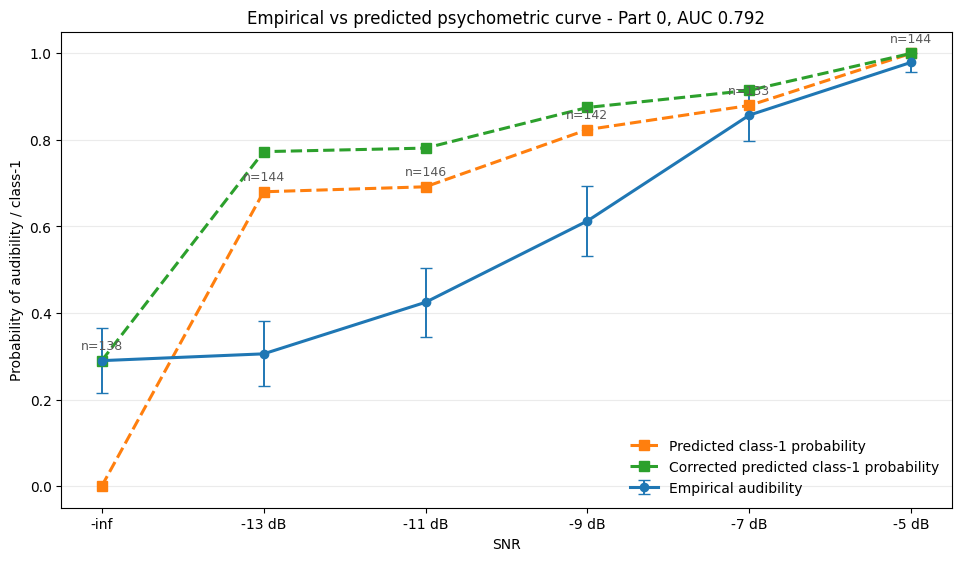

Generating summary plot for participant 1...


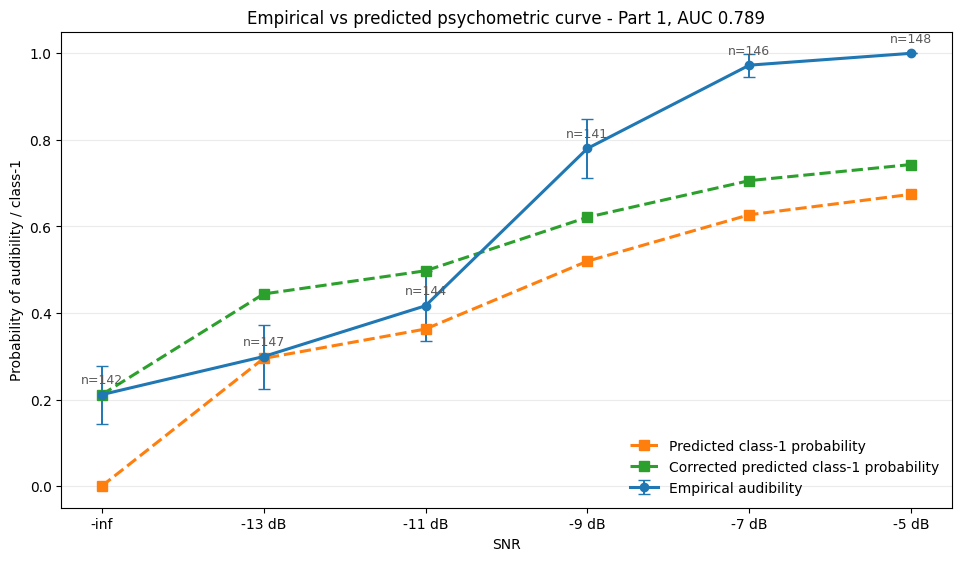

Generating summary plot for participant 2...


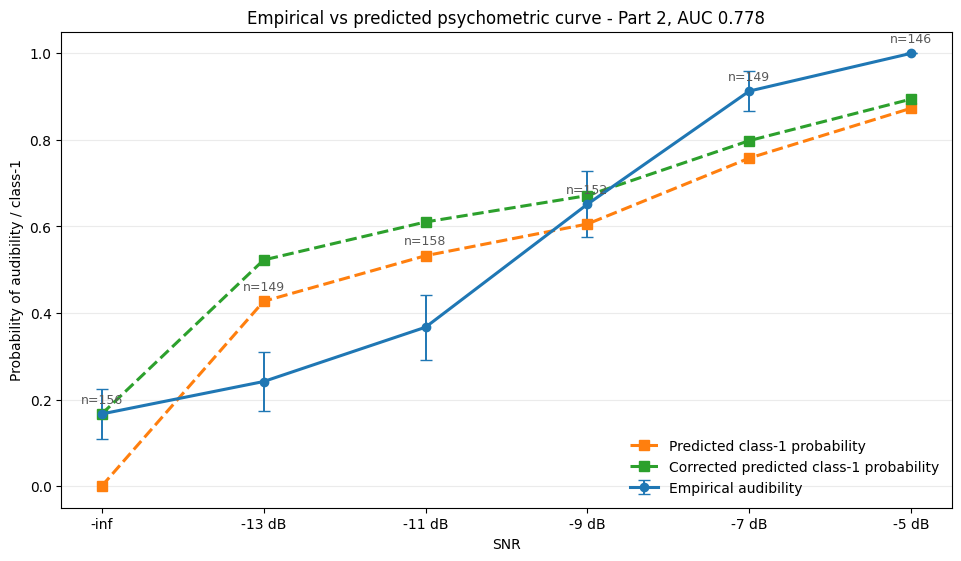

Generating summary plot for participant 3...


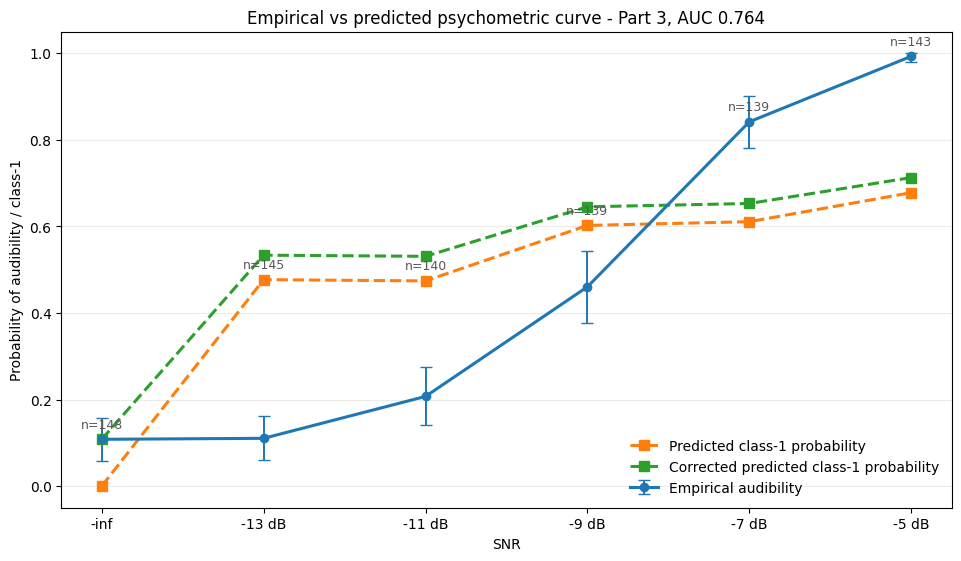

Generating summary plot for participant 4...


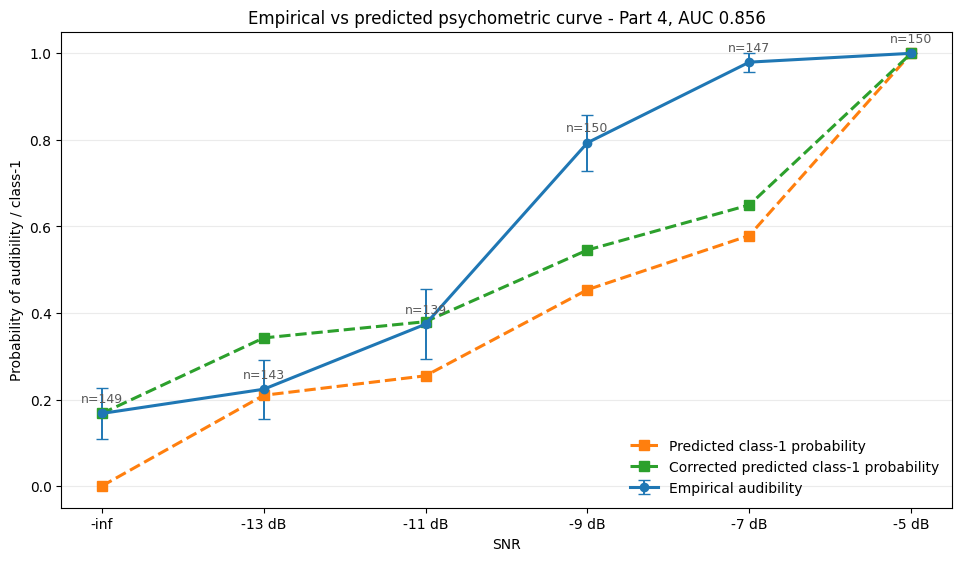

Generating summary plot for participant 5...


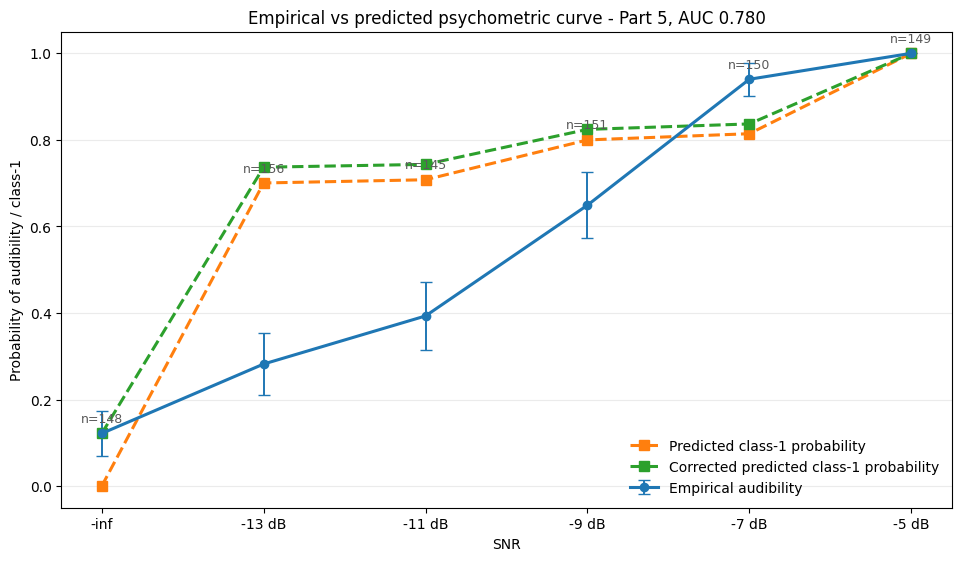

Generating summary plot for participant 6...


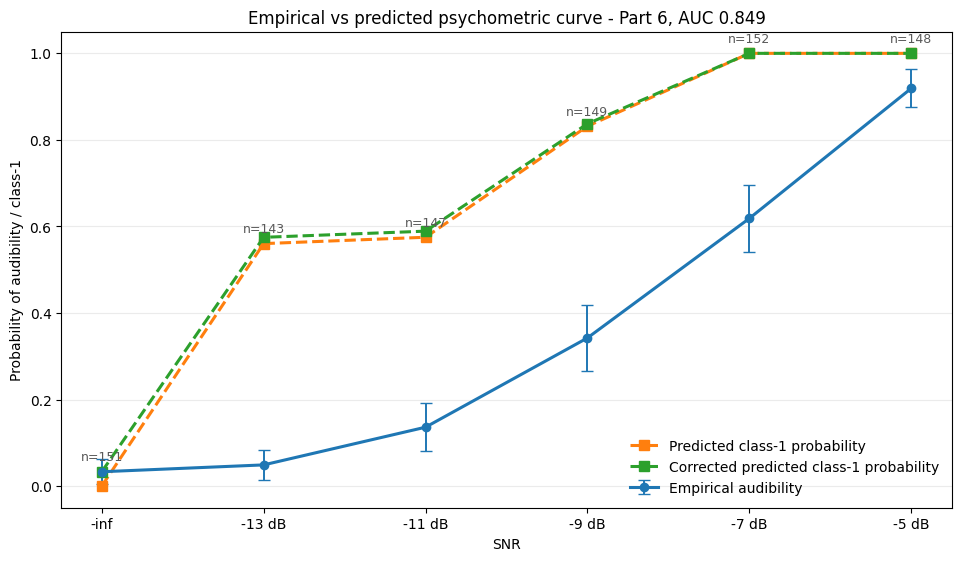

Generating summary plot for participant 7...


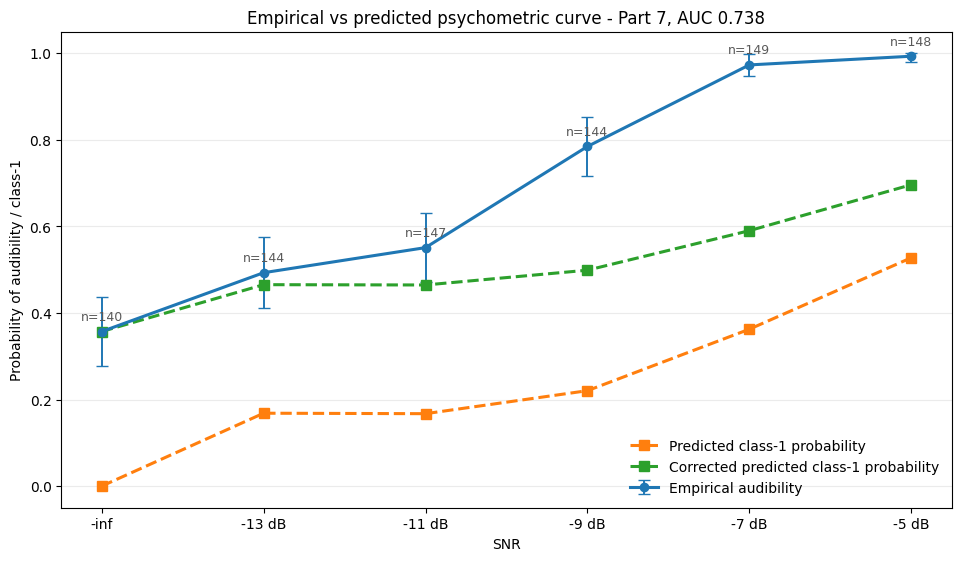

Generating summary plot for participant 8...


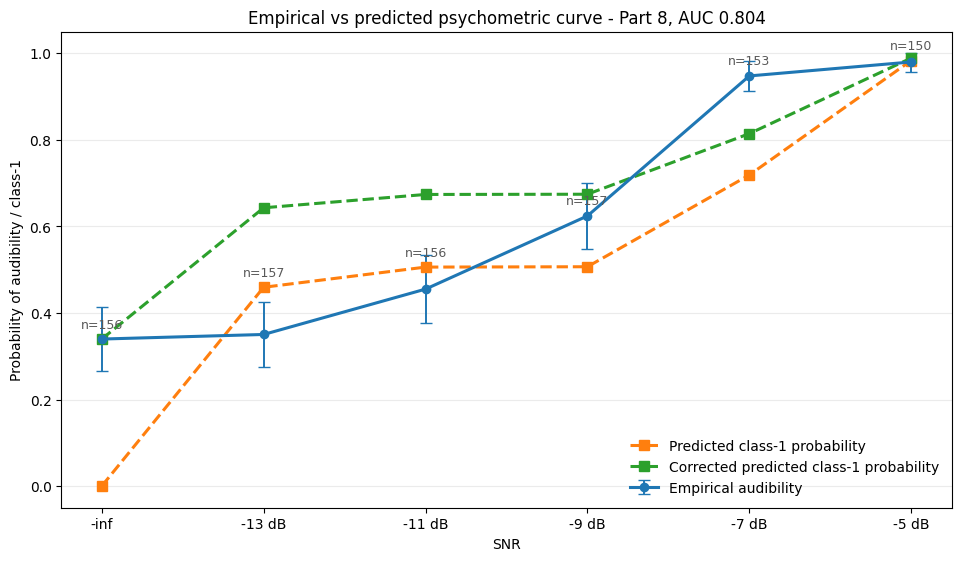

Generating summary plot for participant 9...


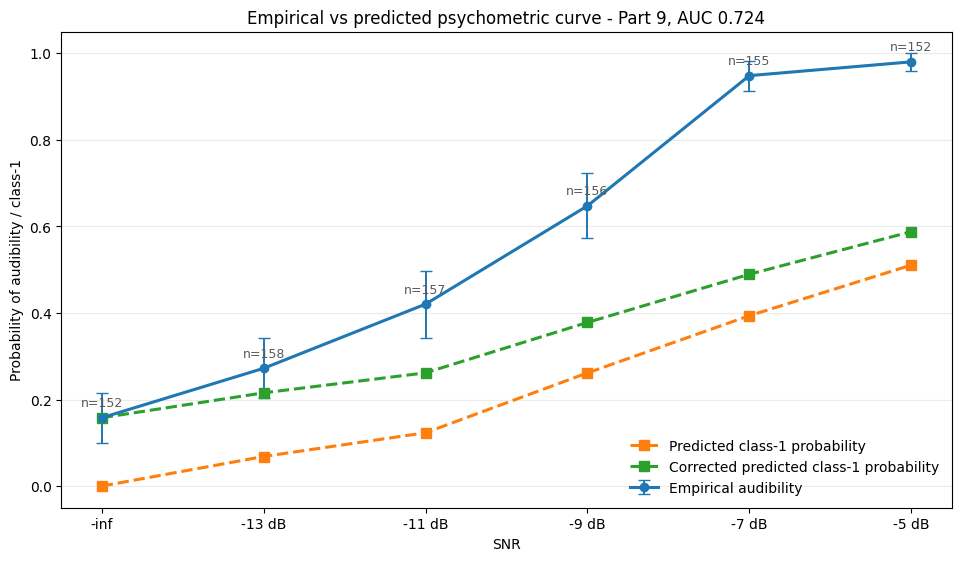

Generating summary plot for participant 10...


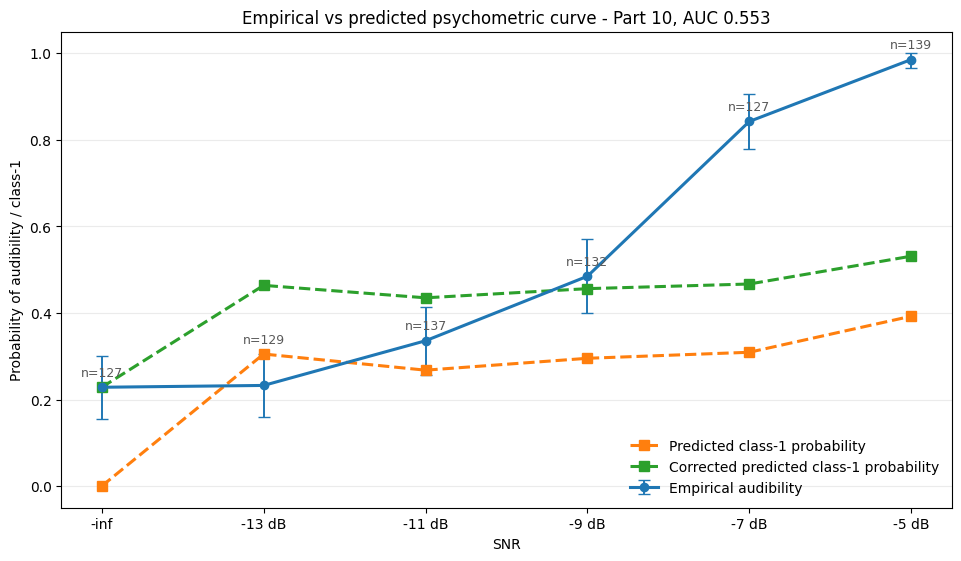

Generating summary plot for participant 11...


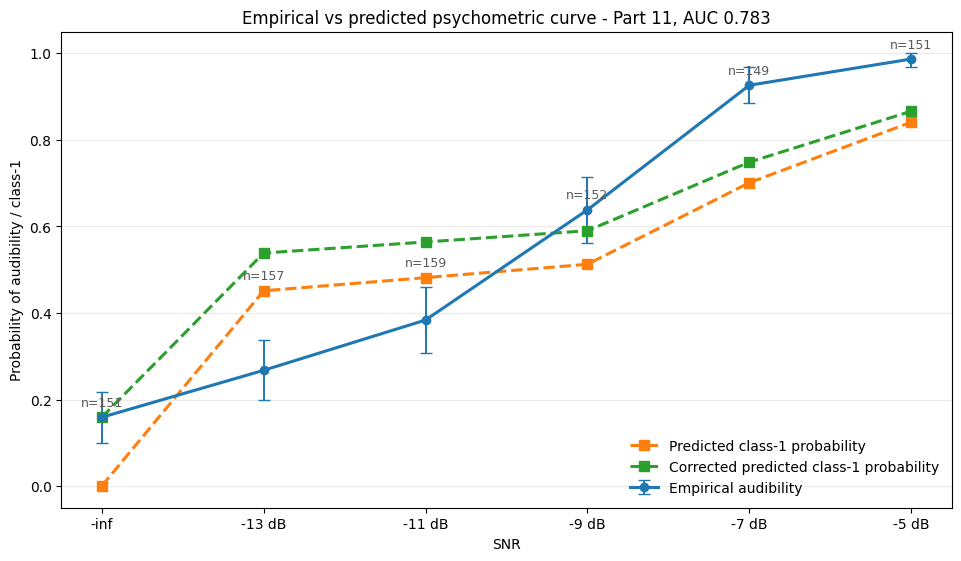

Generating summary plot for participant 12...


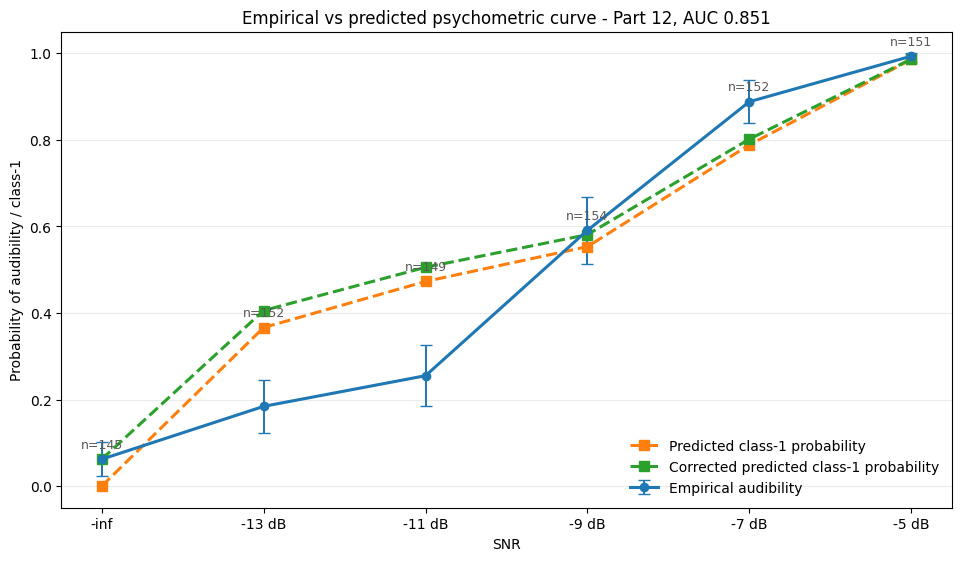

Generating summary plot for participant 13...


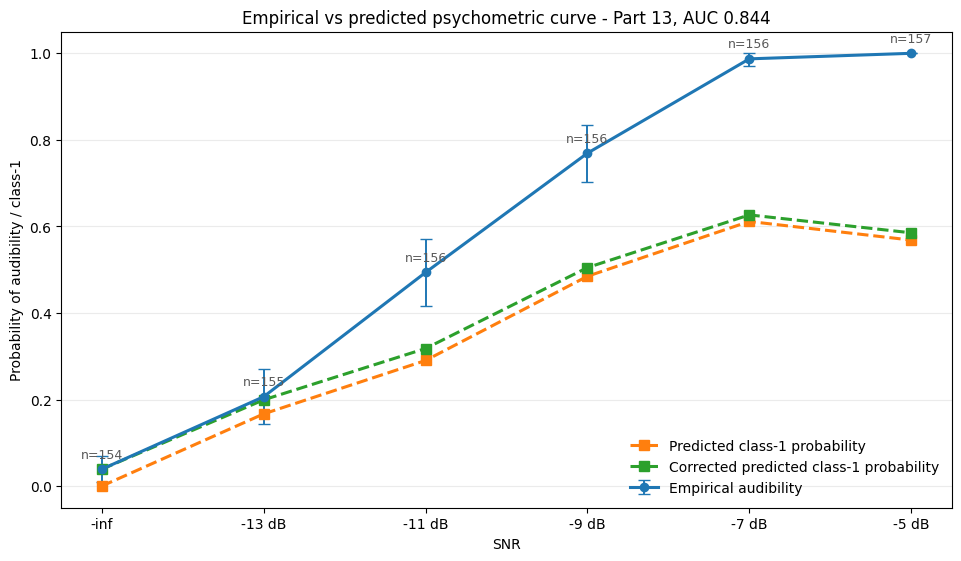

Generating summary plot for participant 14...


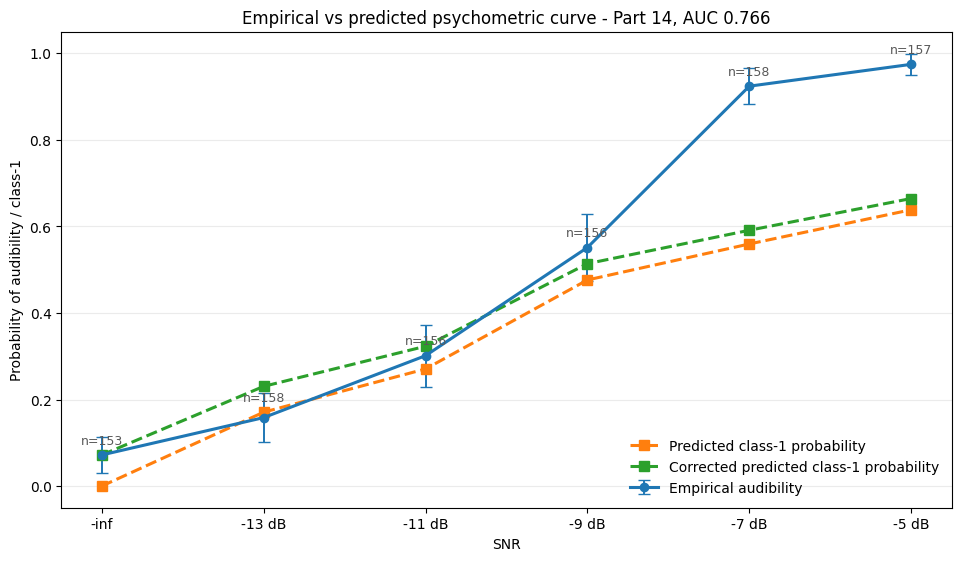

Generating summary plot for participant 15...


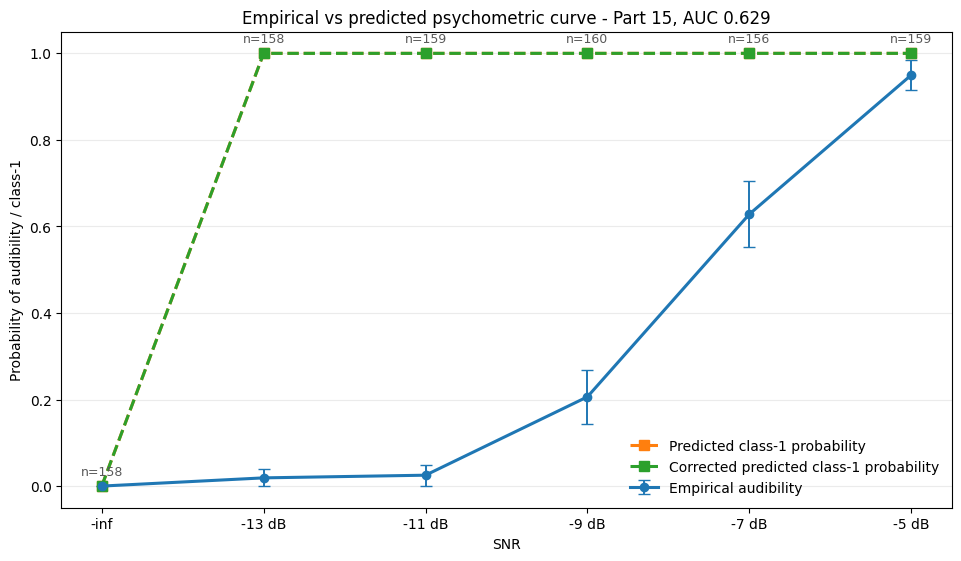

Generating summary plot for participant 16...


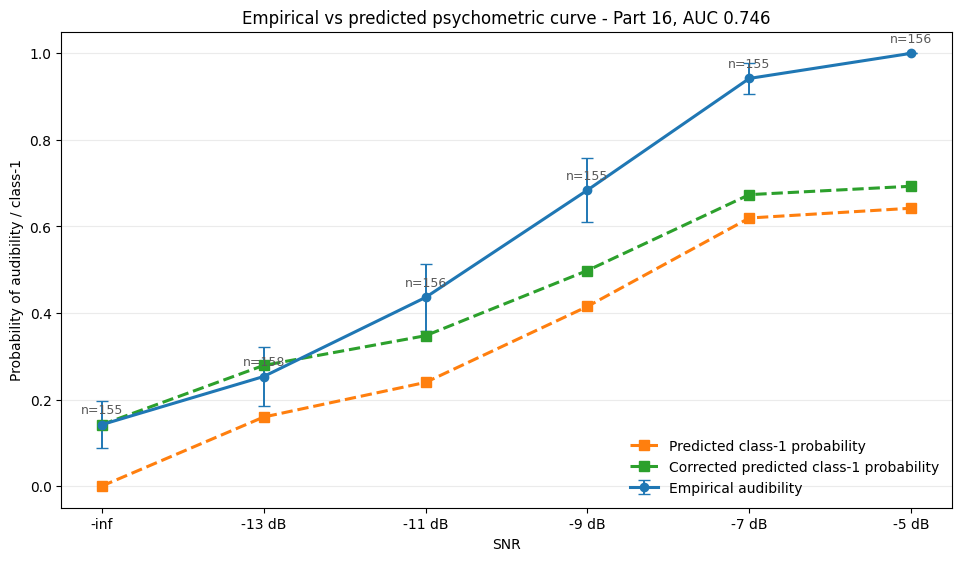

Generating summary plot for participant 17...


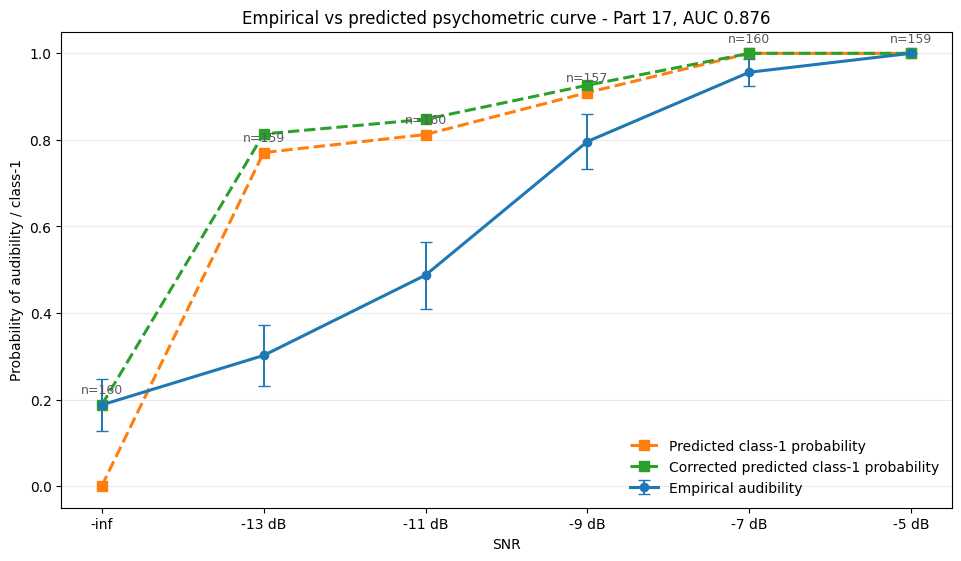

Generating summary plot for participant 18...


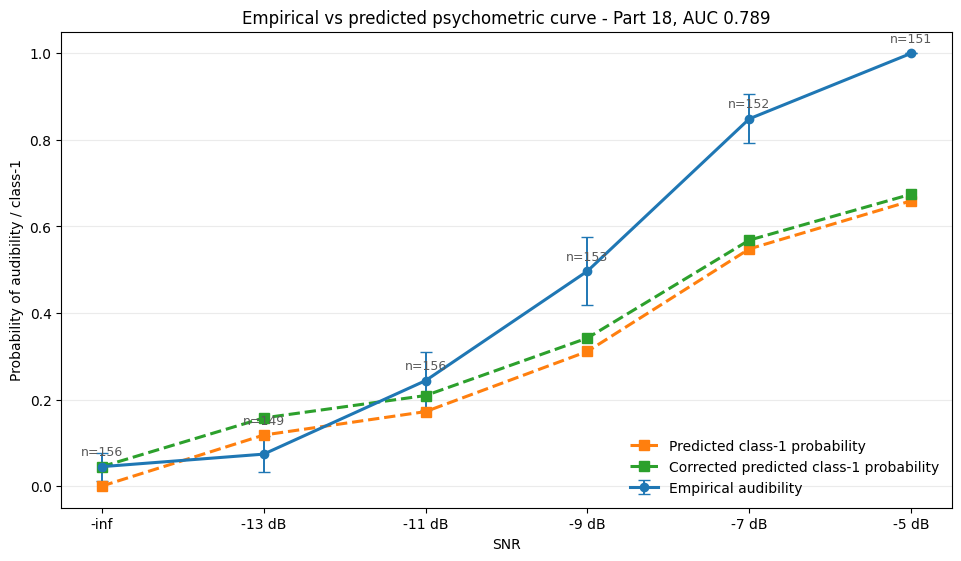

Generating summary plot for participant 19...


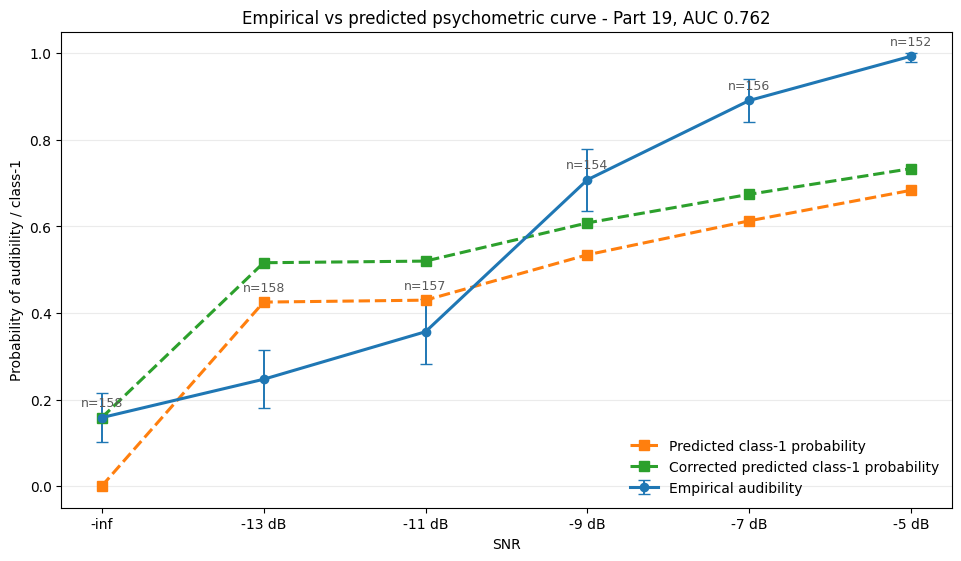

In [23]:
for part in range(20):
    print(f'Generating summary plot for participant {part}...')
    mixture_fits = mixture_fits_dict[part]
    binarized_audibilities = binarized_audibilities_dict[part]
    distributions = distributions_dict[part]

    snr_values = SNRs[:len(categories)]
    snr_labels = [('-inf' if not np.isfinite(v) else f'{int(v)} dB') for v in snr_values]
    x_pos = np.arange(len(categories))

    empirical_mean = []
    predicted_mean = []
    empirical_ci_low = []
    empirical_ci_high = []
    n_per_level = []

    for cat in categories:
        y_true = np.asarray(binarized_audibilities[cat], dtype=int)
        x = np.asarray(distributions[cat], dtype=float)
        fit = mixture_fits[cat]

        if x.size == 0 or y_true.size == 0:
            empirical_mean.append(np.nan)
            predicted_mean.append(np.nan)
            empirical_ci_low.append(np.nan)
            empirical_ci_high.append(np.nan)
            n_per_level.append(0)
            continue

        lam    = fit['lambda']
        p_rest = fit['alpha'] * norm.pdf(x, loc=fit['mu0'], scale=fit['sigma0'])
        p_alt  = (1.0 - fit['alpha']) * skewnorm.pdf(x, a=lam, loc=fit['mu1'], scale=fit['sigma1'])
        p_class1 = p_alt / np.maximum(p_rest + p_alt, 1e-300)

        empirical = float(np.mean(y_true))
        predicted = float(np.mean(p_class1))
        n_obs = int(y_true.size)
        se = np.sqrt(max(empirical * (1.0 - empirical), 0.0) / max(n_obs, 1))
        ci_half_width = 1.96 * se

        empirical_mean.append(empirical)
        predicted_mean.append(predicted)
        empirical_ci_low.append(max(0.0, empirical - ci_half_width))
        empirical_ci_high.append(min(1.0, empirical + ci_half_width))
        n_per_level.append(n_obs)

    empirical_mean     = np.asarray(empirical_mean, dtype=float)
    predicted_mean     = np.asarray(predicted_mean, dtype=float)
    empirical_ci_low   = np.asarray(empirical_ci_low, dtype=float)
    empirical_ci_high  = np.asarray(empirical_ci_high, dtype=float)

    prior_mean = np.asarray([1.0 - mixture_fits[cat]['alpha'] for cat in categories], dtype=float)

    fig, ax = plt.subplots(figsize=(9.5, 5.5), constrained_layout=True)

    ax.errorbar(
        x_pos, empirical_mean,
        yerr=[empirical_mean - empirical_ci_low, empirical_ci_high - empirical_mean],
        fmt='o-', color='tab:blue', ecolor='tab:blue',
        elinewidth=1.4, capsize=4, lw=2.2,
        label='Empirical audibility',
    )
    ax.plot(
        x_pos, predicted_mean,
        's--', color='tab:orange', lw=2.2, ms=7,
        label='Predicted class-1 probability',
    )

    FA_rate = empirical_mean[0]
    corrected_predicted_mean = np.zeros_like(predicted_mean)
    for cat in categories:
        corrected_predicted_mean[cat] = predicted_mean[cat] + FA_rate * (1.0 - predicted_mean[cat])
    ax.plot(
        x_pos, corrected_predicted_mean,
        's--', color='tab:green', lw=2.2, ms=7,
        label='Corrected predicted class-1 probability',
    )

    # ax.plot(x_pos, prior_mean, 'd-.', color='tab:green', lw=2.0, ms=7, label='Prior (1 - alpha)')

    for xp, y_emp, y_pred, n_obs in zip(x_pos, empirical_mean, predicted_mean, n_per_level):
        if np.isfinite(y_emp) and np.isfinite(y_pred):
            ax.annotate(
                f'n={n_obs}', (xp, max(y_emp, y_pred)),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9, color='0.35',
            )

    ax.set_title(f'Empirical vs predicted psychometric curve - Part {part}, AUC {roc_auc_dict[part]:.3f}')
    ax.set_xlabel('SNR')
    ax.set_xticks(x_pos)
    ax.set_xticklabels(snr_labels)
    ax.set_ylabel('Probability of audibility / class-1')
    ax.set_ylim(-0.05, 1.05)
    ax.grid(axis='y', alpha=0.25)
    ax.legend(frameon=False, loc='lower right')

    plt.savefig(f'Behavioral_Predictions/2GM_nopenalty_part{part}.png', dpi=300)
    plt.show()

In [ ]:
# mean AUC for skewed mixture: 0.785 & for 2GM: 0.774
avg_auc = np.mean(list(roc_auc_dict.values()))
print(f'Average ROC AUC across all participants: {avg_auc:.3f}')

Average ROC AUC across all participants: 0.774


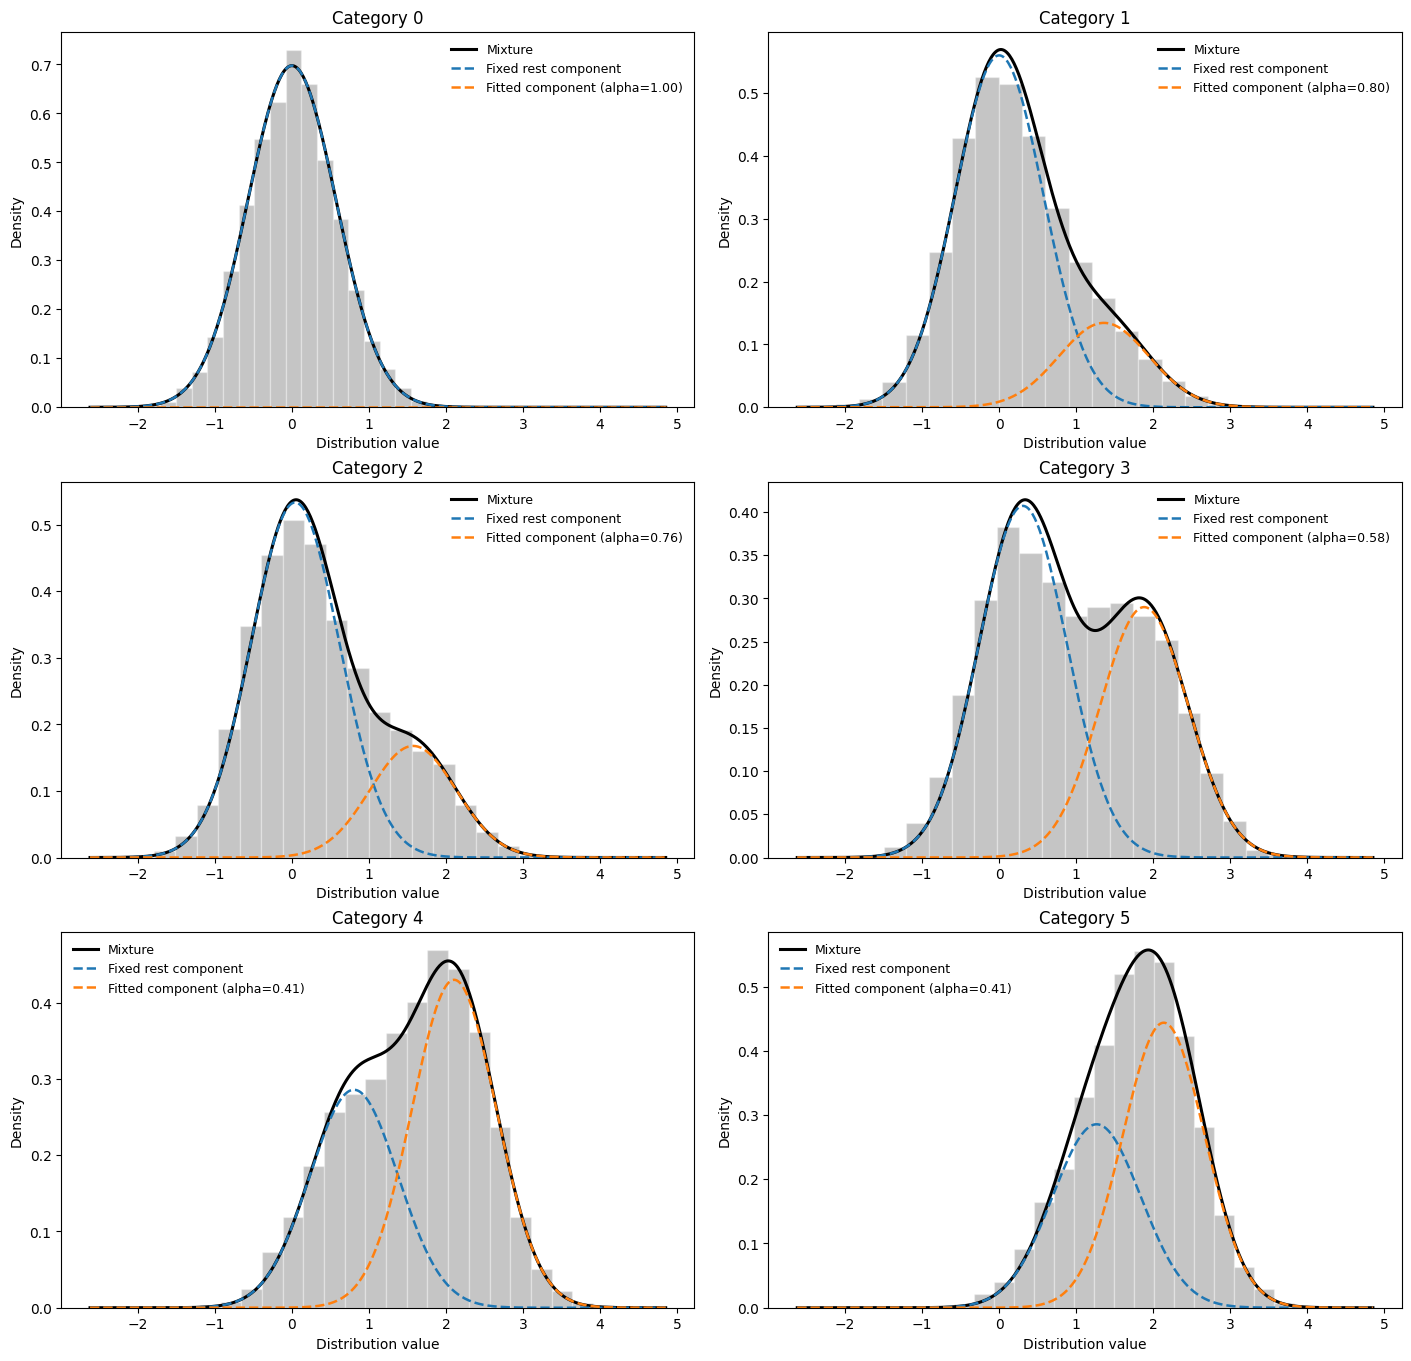

In [6]:
part = 13

n_cols = 2
n_rows = ceil(len(categories) / n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4.5 * n_rows), constrained_layout=True)
axes = np.atleast_1d(axes).ravel()

x_grid = np.linspace(
    min(np.min(measured_distributions_dict[part][cat]) for cat in categories) - 0.5,
    max(np.max(measured_distributions_dict[part][cat]) for cat in categories) + 0.5,
    500,
)

for ax, cat in zip(axes, categories):
    x = np.asarray(measured_distributions_dict[part][cat], dtype=float)
    fit = mixture_fits_dict[part][cat]
    mu0    = fit['mu0']
    sigma0 = fit['sigma0']
    alpha  = fit['alpha']
    mu1    = fit['mu1']
    sigma1 = fit['sigma1']
    lam    = fit['lambda']

    ax.hist(x, bins=20, density=True, alpha=0.35, color='0.35', edgecolor='white')

    p0   = norm.pdf(x_grid, loc=mu0, scale=sigma0)
    p1   = skewnorm.pdf(x_grid, a=lam, loc=mu1, scale=sigma1)
    pmix = alpha * p0 + (1.0 - alpha) * p1

    ax.plot(x_grid, pmix,                  color='black',       lw=2.2, label='Mixture')
    ax.plot(x_grid, alpha * p0,            color='tab:blue',    lw=1.8, ls='--', label='Fixed rest component')
    ax.plot(x_grid, (1.0 - alpha) * p1,   color='tab:orange',  lw=1.8, ls='--', label=f'Fitted component (alpha={alpha:.2f})')

    ax.set_title(f'Category {cat}')
    ax.set_xlabel('Distribution value')
    ax.set_ylabel('Density')
    ax.legend(frameon=False, fontsize=9)

for ax in axes[len(categories):]:
    ax.axis('off')

plt.show()